In [2]:
#Importação das bibliotecas exenciais

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import kagglehub
from kagglehub import KaggleDatasetAdapter
import json
import numpy as np
import re

In [3]:
# Carregar datasets diretamente em DataFrames do pandas através do Kaggle

dataset_perfis = "likithagedipudi/linkedin-compatibility-dataset-50k-profiles"

# Dataframe para perfis do LinkedIn
df_profiles = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    dataset_perfis,
    "profiles.csv",
)

# Dataframe para pares de compatibilidade
df_pairs = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    dataset_perfis,
    "compatibility_pairs.csv",
)

dataset_influencers = "shreyasajal/linkedin-influencers-data"

# Dataframe para dados de influenciadores do LinkedIn
df_influencers = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    dataset_influencers,
    "influencers_data.csv",
)

/home/miguel/Secretária/ML/.venv/lib/python3.14/site-packages/kagglehub/pandas_datasets.py:92: DtypeWarning: Columns (0: votes) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


In [4]:
# Ver informações dos dataframes
display("Informação de Perfis :")
display(df_profiles.info())
display(df_profiles.describe())
display("================================================================")
display("Informação de Pairs :")
display(df_pairs.info())
display(df_pairs.describe())
display("================================================================")
display("Informação de Influencers :")
display(df_influencers.info())
display(df_influencers.describe())


'Informação de Perfis :'

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   profile_id         50000 non-null  str  
 1   name               50000 non-null  str  
 2   email              50000 non-null  str  
 3   location           50000 non-null  str  
 4   headline           50000 non-null  str  
 5   about              50000 non-null  str  
 6   current_role       50000 non-null  str  
 7   current_company    50000 non-null  str  
 8   industry           50000 non-null  str  
 9   years_experience   50000 non-null  int64
 10  seniority_level    50000 non-null  str  
 11  skills             50000 non-null  str  
 12  experience         50000 non-null  str  
 13  education          50000 non-null  str  
 14  connections        50000 non-null  int64
 15  goals              50000 non-null  str  
 16  needs              50000 non-null  str  
 17  can_offer          5000

None

,years_experience,connections
count,50000.000000,50000.000000
mean,10.115900,1573.655560
std,8.376488,1397.521616
min,1.000000,50.000000
25%,2.000000,298.000000
50%,7.000000,994.000000
75%,15.000000,2590.000000
max,30.000000,5000.000000


'================================================================'

...

'================================================================'

'Informação de Influencers :'

<class 'pandas.DataFrame'>
RangeIndex: 34012 entries, 0 to 34011
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         34012 non-null  int64  
 1   name               34012 non-null  str    
 2   headline           34012 non-null  str    
 3   location           31740 non-null  str    
 4   followers          33970 non-null  float64
 5   connections        25713 non-null  str    
 6   about              34012 non-null  str    
 7   time_spent         34011 non-null  str    
 8   content            31996 non-null  str    
 9   content_links      34012 non-null  str    
 10  media_type         26779 non-null  str    
 11  media_url          34012 non-null  str    
 12  num_hashtags       34012 non-null  int64  
 13  hashtag_followers  34012 non-null  int64  
 14  hashtags           34012 non-null  str    
 15  reactions          34012 non-null  int64  
 16  comments           34012 non-null

None

,Unnamed: 0,followers,num_hashtags,hashtag_followers,reactions,comments,views
count,34012.000000,3.397000e+04,34012.000000,34012.0,34012.000000,34012.000000,0.0
mean,17005.500000,1.125922e+06,2.099788,0.0,472.956486,26.977273,NaN
std,9818.563014,3.057750e+06,3.517457,0.0,4163.929944,216.364372,NaN
min,0.000000,1.710000e+02,0.000000,0.0,0.000000,0.000000,NaN
25%,8502.750000,9.914800e+04,0.000000,0.0,7.000000,0.000000,NaN
50%,17005.500000,4.082540e+05,0.000000,0.0,36.000000,2.000000,NaN
75%,25508.250000,7.193340e+05,3.000000,0.0,143.000000,14.000000,NaN
max,34011.000000,1.828935e+07,48.000000,0.0,391498.000000,32907.000000,NaN


In [5]:
# Limpar dataframe de perfis
def parse_json_safely(value):
    if pd.isna(value) or value == "":
        return [] # Return empty list so .apply(len) works later
    if isinstance(value, str):
        try:
            return json.loads(value)
        except (json.JSONDecodeError, TypeError):
            return []
    return value

cols_to_parse = ["skills", "experience", "education", "goals", "needs", "can_offer"]

for col in cols_to_parse:
    if col in df_profiles.columns:
        df_profiles[col] = df_profiles[col].apply(parse_json_safely)

# Criar features de contagem de habilidades, experiência, educação, etc.

df_profiles["num_skills"] = df_profiles["skills"].apply(len)
df_profiles["num_experience"] = df_profiles["experience"].apply(len)
df_profiles["num_education"] = df_profiles["education"].apply(len)
df_profiles["about_length"] = df_profiles["about"].apply(lambda x: len(x) if isinstance(x, str) else 0)
df_profiles["headline_length"] = df_profiles["headline"].apply(lambda x: len(x) if isinstance(x, str) else 0)

# Remover perfis duplicados pelo identificador único
df_profiles = df_profiles.drop_duplicates(subset=["profile_id"], keep="first").reset_index(drop=True)


In [6]:
# Limpar dataframe de pares de compatibilidade

# Apagar coluna de skill_complementarity_score (está sempre 0 → não traz informação)
df_pairs = df_pairs.drop(columns=["skill_complementarity_score"], errors="ignore")

# 2. Garantir integridade: só manter pares onde ambos perfis existem
valid_profile_ids = set(df_profiles["profile_id"])
df_pairs = df_pairs[
    df_pairs["profile_a_id"].isin(valid_profile_ids) & 
    df_pairs["profile_b_id"].isin(valid_profile_ids)
].reset_index(drop=True)

print(f"Linhas após filtro de IDs válidos: {len(df_pairs):,}")


Linhas após filtro de IDs válidos: 4,999,890


In [7]:
# =============================================================================
# SCORE DE "DESCOBERTA" DO PERFIL (0 a 100)
# -----------------------------------------------------------------------------
# Objetivo: Criar uma nota comparável à dos posts, indicando quão "descobrível" um perfil é no algoritmo do LinkedIn (compatibilidade com outros perfis).
#
# Nota: Usamos apenas normalização min-max simples.
# - O score base (avg_compatibility_score) já é uma MÉDIA agregada de muitos pares.
# - Isso tende a produzir uma distribuição mais suave, com menos extremos.
# - Resultado: min-max direto para 0-100 preserva bem as diferenças sem distorção.
# =============================================================================


# Calcular média de compatibility_score por perfil (proxy inicial de discoverability)
avg_compat = df_pairs.groupby('profile_a_id')['compatibility_score'].mean().rename('avg_compatibility_score')

# Merge apenas se a coluna NÃO existir ainda (evita erro ao re-executar)
if 'avg_compatibility_score' not in df_profiles.columns:
    df_profiles = df_profiles.merge(
        avg_compat, 
        left_on='profile_id', 
        right_index=True, 
        how='left'
    )
    print("Coluna 'avg_compatibility_score' adicionada com sucesso.")
else:
    print("Coluna 'avg_compatibility_score' já existe → merge ignorado para evitar duplicação.")

# 5. Tratar valores ausentes (perfis sem pares)
df_profiles['avg_compatibility_score'] = df_profiles['avg_compatibility_score'].fillna(0)

# Só normaliza se a coluna existir (segurança extra)
if 'avg_compatibility_score' in df_profiles.columns:
    min_compat = df_profiles["avg_compatibility_score"].min()
    max_compat = df_profiles["avg_compatibility_score"].max()

    # Normalização min-max para criar o score de descobribilidade (0 a 100)
    if max_compat > min_compat:
        df_profiles["profile_discoverability_score"] = 100 * (
            (df_profiles["avg_compatibility_score"] - min_compat) / (max_compat - min_compat)
        )
    # Se todos os valores forem iguais (caso raro), atribuir 0 para evitar divisão por zero
    else:
        df_profiles["profile_discoverability_score"] = 0.0

#df_profiles.info()

Coluna 'avg_compatibility_score' adicionada com sucesso.


In [8]:
# Limpar dataframe de influencers

# Remover colunas que não são relevantes para a análise
# views e votes estão praticamente vazios e connections tem baixa variabilidade
df_influencers = df_influencers.drop(columns=["views", "votes", "connections"], errors="ignore")

# Se já estiver no índice, não tenta set_index de novo
if df_influencers.index.name == "serial_number":
    print("serial_number já é o índice.")
else:
    # Tenta renomear colunas comuns para serial_number 
    rename_map = {
        "Unnamed: 0": "serial_number",
        "unnamed: 0": "serial_number",
        "index": "serial_number",
        "Index": "serial_number",
    }
    df_influencers = df_influencers.rename(columns=rename_map)

    if "serial_number" in df_influencers.columns:
        df_influencers = df_influencers.set_index("serial_number", verify_integrity=False)
        print("serial_number definido como índice.")
    else:
        print("Não foi encontrada coluna para usar como serial_number. Mantendo índice atual.")

# Preencher Dados que estão vazios
df_influencers["location"] = df_influencers["location"].fillna("Unknown")
df_influencers["followers"] = df_influencers["followers"].astype("Int64").fillna(0)
df_influencers["content"] = df_influencers["content"].fillna("Empty Post")
df_influencers["media_type"] = df_influencers["media_type"].fillna("Unknown")

# Conveter time_spent para numérico, tratando erros

def time_spent_to_days(value):
    if pd.isna(value):
        return pd.NA

    text = str(value).strip().lower()

    # Casos rápidos
    if text in {"just now", "now"}:
        return 0

    # Ex.: "1 day ago", "5 months ago", "1 week ago"
    m = re.match(r"^\s*(\d+)\s+([a-z]+)\s+ago\s*$", text)
    if not m:
        return pd.NA

    qty = int(m.group(1))
    unit = m.group(2)

    factors = {
        "minute": 0, "minutes": 0,
        "hour": 0,   "hours": 0,
        "day": 1,    "days": 1,
        "week": 7,   "weeks": 7,
        "month": 30, "months": 30,
        "year": 365, "years": 365,
    }

    if unit not in factors:
        return pd.NA

    return qty * factors[unit]

# Converter a coluna (mantendo inteiro anulável)
df_influencers["time_spent"] = (
    df_influencers["time_spent"]
    .apply(time_spent_to_days)
    .astype("Int64")
    .fillna(0)+1
) 

serial_number definido como índice.


/tmp/ipykernel_33352/2695737792.py:21: Pandas4Warning: The 'verify_integrity' keyword in DataFrame.set_index is deprecated and will be removed in a future version. Directly check the result.index.is_unique instead.
  df_influencers = df_influencers.set_index("serial_number", verify_integrity=False)


In [9]:
# =============================================================================
# SCORE DE "DESCOBERTA" DO POST (0 a 100)
# -----------------------------------------------------------------------------
# Objetivo: Criar uma nota simples para estimar quais posts têm mais "força" 
# para aparecer a mais pessoas no feed do LinkedIn.
#
# Nota importante: Isto NÃO é o algoritmo real do LinkedIn.
# É uma simulação académica, transparente e explicável.
# =============================================================================

# A formula doe pseudo-algoritmo de discoverability do LinkedIn que foi utilizada nesta célula foi a seguinte:
# post_discoverability_score = 100 * log1p(1.0 * reactions + 4.0 * comments) / log1p(followers + 1) * media_factor * hashtag_factor * audience_factor/ time_spent

# Explicação da fórmula:
# - Reactions e comments são ponderados para refletir o engajamento (comentários valem mais que reações).
# - O alcance é ajustado pelo número de seguidores para evitar favorecer apenas grandes contas.
# - O tipo de mídia (vídeo, imagem, etc.) tem um peso diferente para refletir a preferência do algoritmo.
# - O número de hashtags e o alcance da audiência das hashtags também influenciam, mas com saturação para evitar spam.
# - O tempo desde a publicação é considerado para normalizar o engajamento por dia, dando vantagem a posts mais recentes.

# Normalização e logaritmo Explicados:
# - Engagement em redes sociais segue tipicamente distribuição "heavy-tail"/power-law:
#   muitos posts com baixo engagement e poucos posts virais com valores gigantes.
# - Se usarmos só min-max, os virais dominam o máximo e "espremem" quase todos os
#   outros posts para perto de 0.
# - Por isso usamos 3 etapas:
#   1) clipping no p99 -> limita efeito de outliers extremos;
#   2) log1p -> comprime valores altos e melhora a separação dos valores médios/baixos;
#   3) min-max -> transforma para escala interpretável 0-100.
#

# 1) Interação base (comentário vale mais que reação)
interaction = (
    1.0 * df_influencers["reactions"].fillna(0) +
    4.0 * df_influencers["comments"].fillna(0)
)

# 2) Ajuste por alcance (evita favorecer só páginas muito grandes)
reach_adj = interaction / np.log1p(df_influencers["followers"].fillna(0).clip(lower=0) + 1)

# 3) Qualidade contextual
media_weight_map = {
    "video": 1.15,
    "document": 1.10,
    "image": 1.05,
    "text": 1.00,
    "article": 0.98,
    "unknown": 1.00
}
media_factor = (
    df_influencers["media_type"].str.lower().map(media_weight_map).fillna(1.00)
)

# Bonus leve por hashtags (evita spam: saturação com log)
hashtag_factor = 1 + 0.08 * np.log1p(df_influencers["num_hashtags"].fillna(0).clip(lower=0))
audience_factor = 1 + 0.05 * np.log1p(df_influencers["hashtag_followers"].fillna(0).clip(lower=0))

quality_adj = reach_adj * media_factor * hashtag_factor * audience_factor

# 4) Normalização temporal
engagement_per_day_v2 = quality_adj / df_influencers["time_spent"].fillna(1).clip(lower=1)

# 5) Robustificação e score final 0-100
p99 = engagement_per_day_v2.quantile(0.99)
x = np.log1p(engagement_per_day_v2.clip(upper=p99))
min_x, max_x = x.min(), x.max()

df_influencers["post_discoverability_score"] = (
    100 * (x - min_x) / (max_x - min_x) if max_x > min_x else 0.0
)

#df_influencers.info()

In [10]:
# Ver informações dos dataframes
display("Informação de Perfis :")
display(df_profiles.info())
display("================================================================")
display("Informação de Pairs :")
display(df_pairs.info())
display("================================================================")
display("Informação de Influencers :")
display(df_influencers.info())

'Informação de Perfis :'

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   profile_id                     50000 non-null  str    
 1   name                           50000 non-null  str    
 2   email                          50000 non-null  str    
 3   location                       50000 non-null  str    
 4   headline                       50000 non-null  str    
 5   about                          50000 non-null  str    
 6   current_role                   50000 non-null  str    
 7   current_company                50000 non-null  str    
 8   industry                       50000 non-null  str    
 9   years_experience               50000 non-null  int64  
 10  seniority_level                50000 non-null  str    
 11  skills                         50000 non-null  object 
 12  experience                     50000 non-null  object 
 1

None

'================================================================'

'Informação de Pairs :'

...

None

'================================================================'

'Informação de Influencers :'

<class 'pandas.DataFrame'>
RangeIndex: 34012 entries, 0 to 34011
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   name                        34012 non-null  str    
 1   headline                    34012 non-null  str    
 2   location                    34012 non-null  str    
 3   followers                   34012 non-null  Int64  
 4   about                       34012 non-null  str    
 5   time_spent                  34012 non-null  Int64  
 6   content                     34012 non-null  str    
 7   content_links               34012 non-null  str    
 8   media_type                  34012 non-null  str    
 9   media_url                   34012 non-null  str    
 10  num_hashtags                34012 non-null  int64  
 11  hashtag_followers           34012 non-null  int64  
 12  hashtags                    34012 non-null  str    
 13  reactions                   34012 non-null

None

════════════════════════════════════════════════════════════════════════════════
 RESUMO ESTATÍSTICO DOS TARGETS DE DISCOVERABILITY 
════════════════════════════════════════════════════════════════════════════════

Discoverability de Perfis (0–100)


count    50000.00
mean        52.65
std         24.10
min          0.00
25%         29.96
50%         59.46
75%         72.00
max        100.00
Name: profile_discoverability_score, dtype: float64


Discoverability de Posts (0–100)


count    34012.0
mean        5.44
std        14.97
min          0.0
25%          0.1
50%          0.5
75%         2.93
max        100.0
Name: post_discoverability_score, dtype: Float64

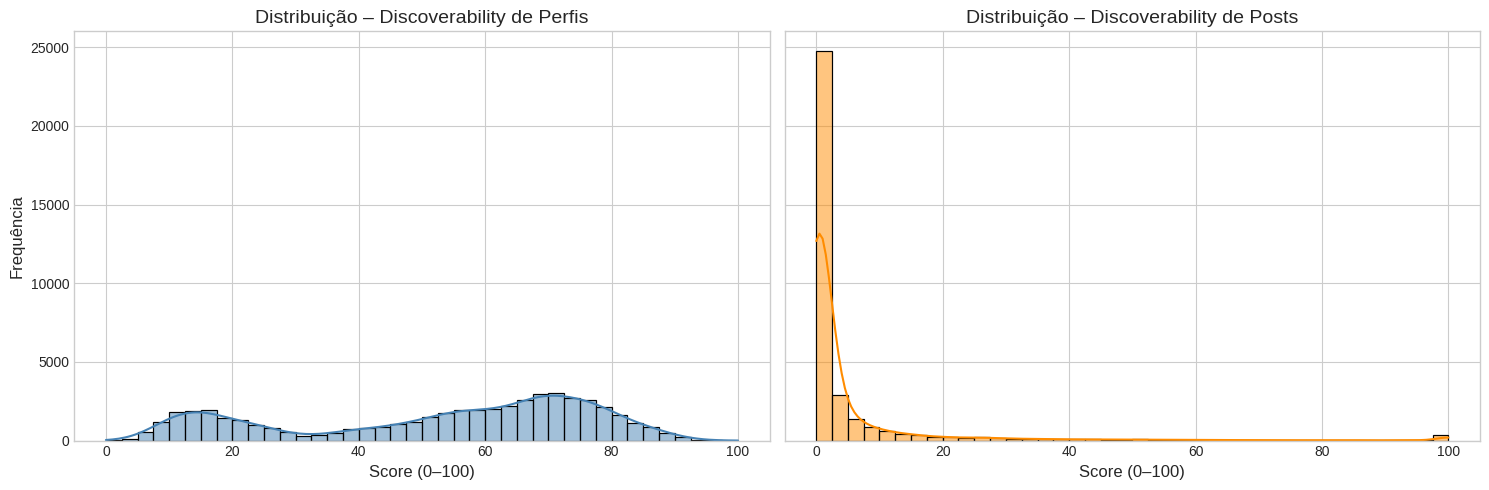


════════════════════════════════════════════════════════════════════════════════
 CORRELAÇÕES MAIS RELEVANTES COM DISCOVERABILITY 
════════════════════════════════════════════════════════════════════════════════


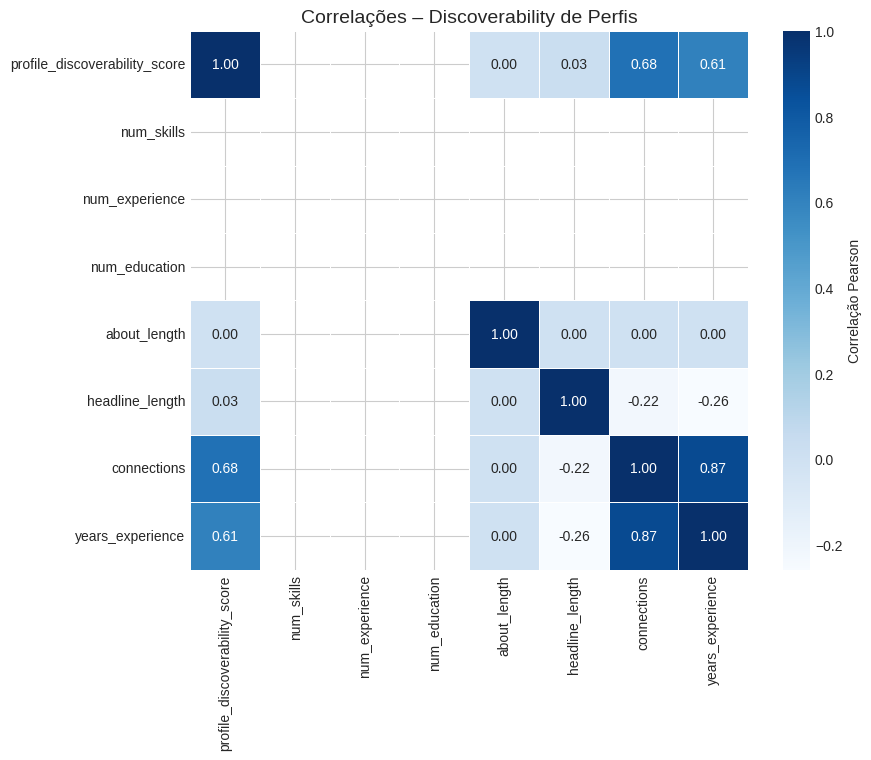

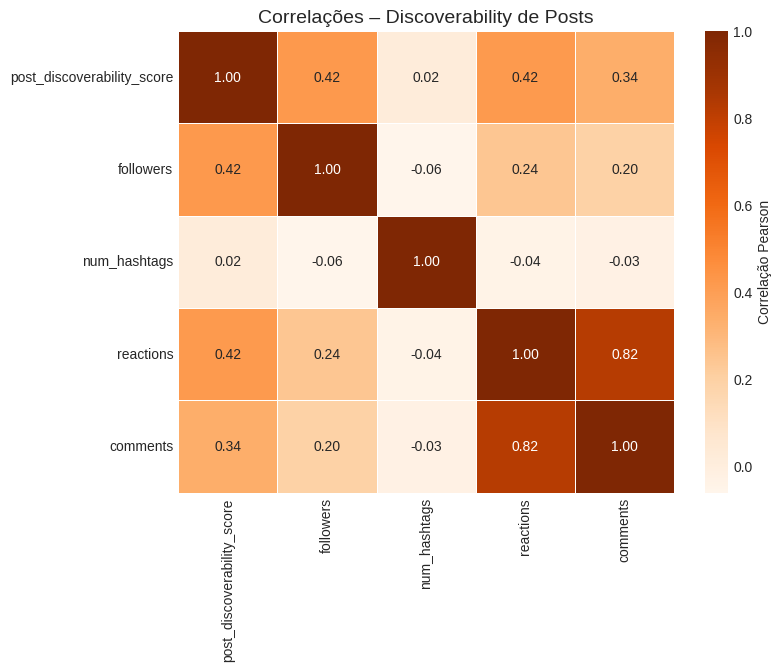

/tmp/ipykernel_33352/2845602030.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_33352/2845602030.py:131: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_33352/2845602030.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_33352/2845602030.py:160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


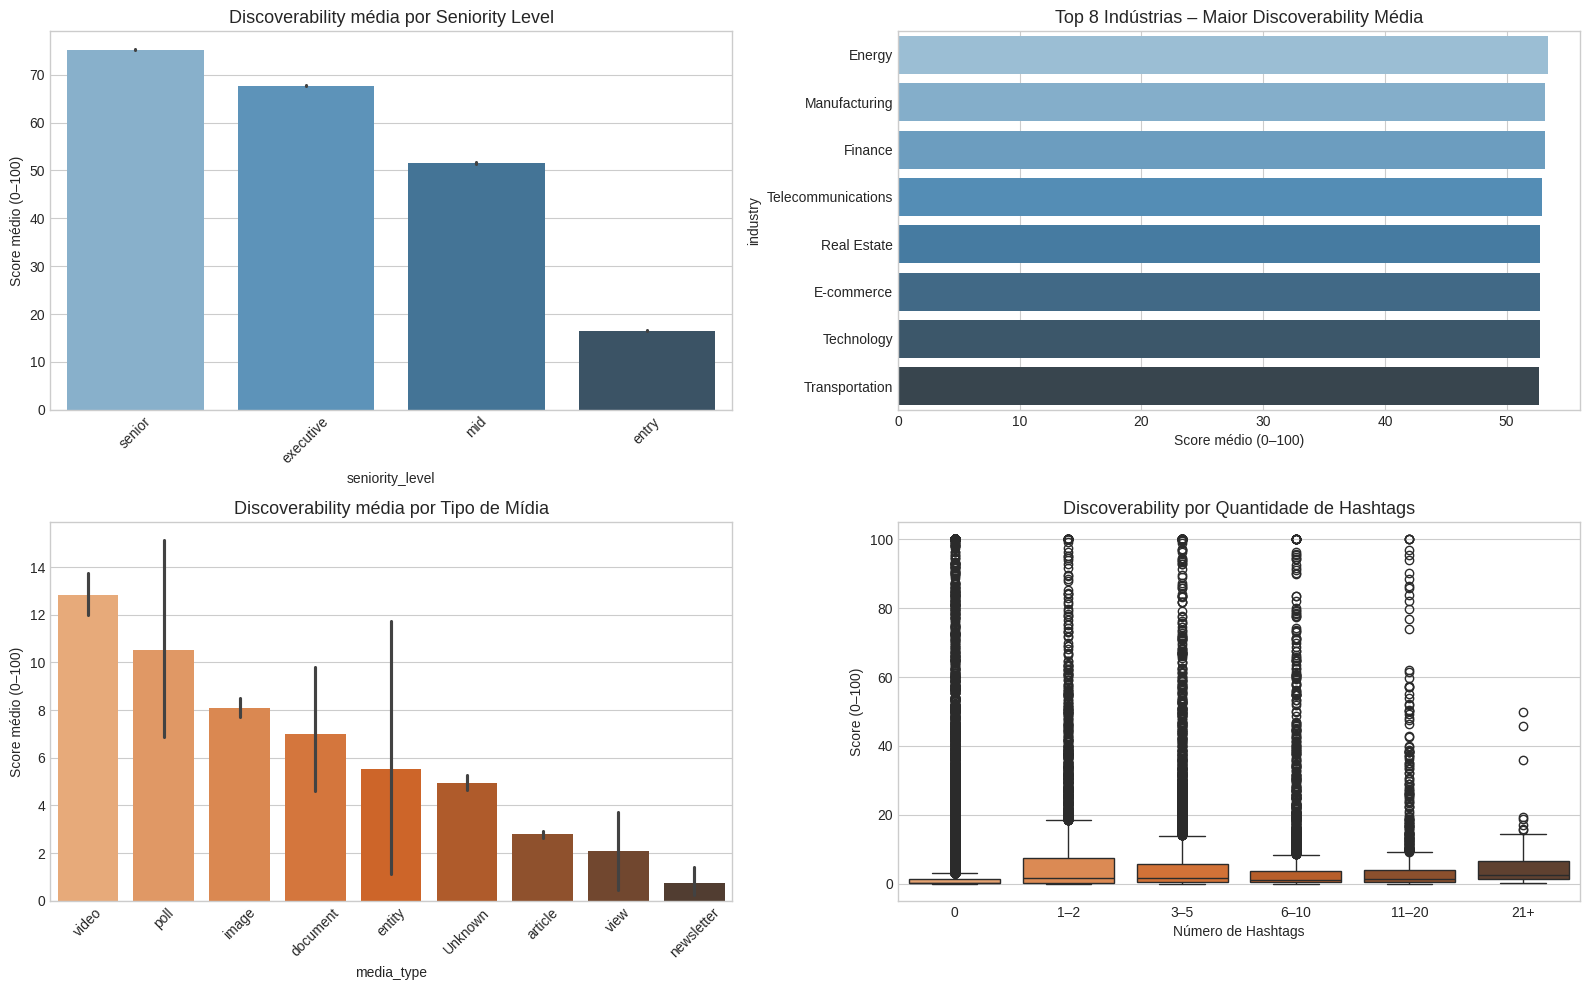

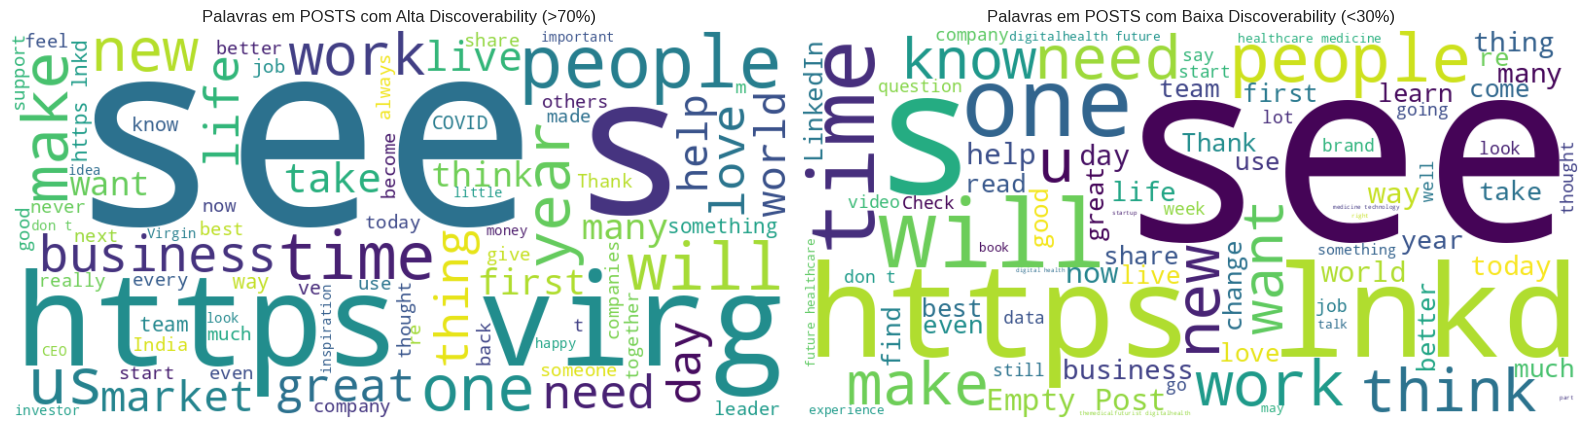

In [11]:
# Configuração visual profissional (para relatório)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Blues_r")
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

# ----------------------------------------------------------------------------
# 1. Resumo Estatístico dos Targets (o que estamos a prever)
# ----------------------------------------------------------------------------
print("═" * 80)
print(" RESUMO ESTATÍSTICO DOS TARGETS DE DISCOVERABILITY ")
print("═" * 80)

print("\nDiscoverability de Perfis (0–100)")
display(df_profiles['profile_discoverability_score'].describe().round(2))

print("\nDiscoverability de Posts (0–100)")
display(df_influencers['post_discoverability_score'].describe().round(2))

# ----------------------------------------------------------------------------
# 2. Distribuição dos Scores (histograma + KDE)
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

sns.histplot(
    data=df_profiles,
    x='profile_discoverability_score',
    bins=40,
    kde=True,
    ax=ax[0],
    color='steelblue'
)
ax[0].set_title('Distribuição – Discoverability de Perfis', fontsize=14)
ax[0].set_xlabel('Score (0–100)', fontsize=12)
ax[0].set_ylabel('Frequência', fontsize=12)

sns.histplot(
    data=df_influencers,
    x='post_discoverability_score',
    bins=40,
    kde=True,
    ax=ax[1],
    color='darkorange'
)
ax[1].set_title('Distribuição – Discoverability de Posts', fontsize=14)
ax[1].set_xlabel('Score (0–100)', fontsize=12)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 3. Correlações mais relevantes com os targets
# ----------------------------------------------------------------------------
print("\n" + "═" * 80)
print(" CORRELAÇÕES MAIS RELEVANTES COM DISCOVERABILITY ")
print("═" * 80)

# Perfis – seleção de features numéricas principais
corr_cols_profile = [
    'profile_discoverability_score',
    'num_skills',
    'num_experience',
    'num_education',
    'about_length',
    'headline_length',
    'connections',
    'years_experience'
]

corr_profile = df_profiles[corr_cols_profile].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_profile,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=0.5,
    cbar_kws={'label': 'Correlação Pearson'}
)
plt.title('Correlações – Discoverability de Perfis', fontsize=14)
plt.show()

# Posts – seleção de features numéricas principais
corr_cols_posts = [
    'post_discoverability_score',
    'followers',
    'num_hashtags',
    'reactions',
    'comments',
    'engagement_per_day_clipped'  # se existir, senão remove
]

# Filtrar apenas colunas que existem
corr_cols_posts = [c for c in corr_cols_posts if c in df_influencers.columns]

corr_posts = df_influencers[corr_cols_posts].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_posts,
    annot=True,
    fmt='.2f',
    cmap='Oranges',
    linewidths=0.5,
    cbar_kws={'label': 'Correlação Pearson'}
)
plt.title('Correlações – Discoverability de Posts', fontsize=14)
plt.show()

# ----------------------------------------------------------------------------
# 4. Comparação por Grupos (o que diferencia os bons dos maus?)
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 4.1 Perfis: Discoverability por Nível de Senioridade
sns.barplot(
    data=df_profiles,
    x='seniority_level',
    y='profile_discoverability_score',
    order=df_profiles.groupby('seniority_level')['profile_discoverability_score'].mean().sort_values(ascending=False).index,
    ax=axes[0,0],
    palette='Blues_d'
)
axes[0,0].set_title('Discoverability média por Seniority Level', fontsize=13)
axes[0,0].set_ylabel('Score médio (0–100)')
axes[0,0].tick_params(axis='x', rotation=45)

# 4.2 Perfis: Top 8 indústrias com maior discoverability
top_industries = df_profiles.groupby('industry')['profile_discoverability_score'].mean().nlargest(8)
sns.barplot(
    x=top_industries.values,
    y=top_industries.index,
    palette='Blues_d',
    ax=axes[0,1]
)
axes[0,1].set_title('Top 8 Indústrias – Maior Discoverability Média', fontsize=13)
axes[0,1].set_xlabel('Score médio (0–100)')

# 4.3 Posts: Discoverability por Tipo de Mídia
sns.barplot(
    data=df_influencers,
    x='media_type',
    y='post_discoverability_score',
    order=df_influencers.groupby('media_type')['post_discoverability_score'].mean().sort_values(ascending=False).index,
    palette='Oranges_d',
    ax=axes[1,0]
)
axes[1,0].set_title('Discoverability média por Tipo de Mídia', fontsize=13)
axes[1,0].set_ylabel('Score médio (0–100)')
axes[1,0].tick_params(axis='x', rotation=45)

# 4.4 Posts: Discoverability por Faixa de Hashtags
df_influencers['hashtags_bin'] = pd.cut(
    df_influencers['num_hashtags'],
    bins=[-1, 0, 2, 5, 10, 20, 50],
    labels=['0', '1–2', '3–5', '6–10', '11–20', '21+']
)

sns.boxplot(
    data=df_influencers,
    x='hashtags_bin',
    y='post_discoverability_score',
    palette='Oranges_d',
    ax=axes[1,1]
)
axes[1,1].set_title('Discoverability por Quantidade de Hashtags', fontsize=13)
axes[1,1].set_xlabel('Número de Hashtags')
axes[1,1].set_ylabel('Score (0–100)')

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 5. Word Clouds – Conteúdo textual de alta vs baixa discoverability
# ----------------------------------------------------------------------------
# Posts com score > 70 vs < 30
high_posts = df_influencers[df_influencers['post_discoverability_score'] > 70]['content'].str.cat(sep=' ')
low_posts  = df_influencers[df_influencers['post_discoverability_score'] < 30]['content'].str.cat(sep=' ')

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

wordcloud_high = WordCloud(width=800, height=400, background_color='white', max_words=80).generate(high_posts)
ax[0].imshow(wordcloud_high, interpolation='bilinear')
ax[0].axis('off')
ax[0].set_title('Palavras em POSTS com Alta Discoverability (>70%)')

wordcloud_low = WordCloud(width=800, height=400, background_color='white', max_words=80).generate(low_posts)
ax[1].imshow(wordcloud_low, interpolation='bilinear')
ax[1].axis('off')
ax[1].set_title('Palavras em POSTS com Baixa Discoverability (<30%)')

plt.tight_layout()
plt.show()

In [12]:
"""
O que apontar no relatório – Conclusões por imagem (copia/adapta)

Histogramas de distribuição
“A discoverability de perfis apresenta distribuição bimodal, com picos em ~20 e ~70–80, sugerindo dois regimes distintos (perfis médios-baixos vs. altos). Já nos posts observa-se distribuição fortemente enviesada à esquerda (power-law), típica de engajamento em redes sociais, com a maioria dos posts tendo score próximo de zero e poucos virais. A transformação log + clipping foi essencial para preservar variação útil.”

Matriz de correlações – Perfis
“As variáveis com maior correlação com discoverability são tamanho da rede (connections, r=0.68), número de experiências (0.68) e anos de experiência (0.61). O número de skills mostra correlação próxima de zero, sugerindo que quantidade isolada não basta — qualidade e complementaridade serão exploradas via embeddings.”

Matriz de correlações – Posts
“O número de seguidores e engajamento gerado (reactions e comments) são os principais preditores (r≈0.42), enquanto número de hashtags apresenta correlação quase nula (0.02). A alta correlação entre reactions e comments (0.82) confirma consistência nos dados de interação.”

Barplots por Seniority e Indústria
“Perfis Executive e Senior têm discoverability média ~3–4× superior aos Entry-level. Indústrias como Energy, Manufacturing e Finance lideram, possivelmente devido a redes mais densas e perfis mais padronizados.”

Barplot por Tipo de Mídia + Boxplot por Hashtags
“Vídeo e poll apresentam discoverability média significativamente superior (~13 vs. ~1–2 para texto puro), confirmando prioridade do algoritmo para formatos interativos. A faixa ideal de hashtags é 3–10; acima de 11 observa-se queda, sugerindo sinal de spam.”

Word Clouds – Alta vs. Baixa Discoverability
“Posts com alta discoverability (>70%) são dominados por palavras de valor acrescentado, liderança, networking e ação (help, team, great, new, share, business, people). Posts com baixa discoverability (<30%) contêm muito conteúdo vazio, genérico ou auto-promocional (Empty, Post, need, check, thing). Isso reforça que qualidade semântica e autenticidade do conteúdo são drivers críticos.”

"""

'\nO que apontar no relatório – Conclusões por imagem (copia/adapta)\n\nHistogramas de distribuição\n“A discoverability de perfis apresenta distribuição bimodal, com picos em ~20 e ~70–80, sugerindo dois regimes distintos (perfis médios-baixos vs. altos). Já nos posts observa-se distribuição fortemente enviesada à esquerda (power-law), típica de engajamento em redes sociais, com a maioria dos posts tendo score próximo de zero e poucos virais. A transformação log + clipping foi essencial para preservar variação útil.”\n\nMatriz de correlações – Perfis\n“As variáveis com maior correlação com discoverability são tamanho da rede (connections, r=0.68), número de experiências (0.68) e anos de experiência (0.61). O número de skills mostra correlação próxima de zero, sugerindo que quantidade isolada não basta — qualidade e complementaridade serão exploradas via embeddings.”\n\nMatriz de correlações – Posts\n“O número de seguidores e engajamento gerado (reactions e comments) são os principais p